# 🏥 Healthcare ML Platform
## Notebook 08 — Treatment Recommendation Engine

**Dataset:**  `data/processed/treatment_lookup.csv`  
**Output:**   `models/knn_recommender.pkl`

### What is a recommendation engine?
A recommendation engine finds patterns between users or items  
and suggests something relevant based on similarity.

In our case:
- **User** = a new patient
- **Items** = medications
- **Similarity** = patients with similar health profiles
  (age, time in hospital, number of medications, diagnoses)

### How our engine works
```
New patient arrives with health profile
          ↓
Find the 5 most similar past patients (kNN)
          ↓
Look at what medications those 5 patients used
          ↓
Recommend the most commonly used medications
```

### Why kNN for recommendation?
k-Nearest Neighbours is the simplest and most interpretable  
recommendation approach for tabular medical data.    
It asks one simple question: "Who is most similar to this patient?"

---
> This is **content-based filtering** —  
> we recommend based on patient features, not rating history.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=(10,5)

---
## Step 1 — Load the Treatment Data

`treatment_lookup.csv` was created in Notebook 02.  
It contains only the columns we need:
- **Feature columns** — patient health profile
- **Medication columns** — what medications they received

This is the "interaction history" that makes recommendation possible.  
Every row is one past patient admission we can learn from.

In [2]:
df = pd.read_csv('../Dataset/processed/treatment_lookup.csv')

print(f"Shape   : {df.shape}")
print(f"\nColumns : {list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape   : (101766, 15)

Columns : ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']

First 3 rows:


,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,metformin,repaglinide,nateglinide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin
0,5,1,41,0,1,1,No,No,No,No,No,No,No,No,No
1,15,3,59,0,18,9,No,No,No,No,No,No,No,No,Up
2,25,2,11,5,13,6,No,No,No,No,Steady,No,No,No,No


---
## Step 2 — Define Feature and Medication Columns

We split the columns into two groups:

**Feature columns** — used to measure similarity between patients.  
These are the health profile inputs a doctor would know about a new patient.

**Medication columns** — what we recommend.  
These are what past similar patients actually received.

The kNN model only sees the feature columns when finding similar patients.  
The medication columns are only looked up AFTER the similar patients are found.

In [3]:
#columns used to find similar patients
feature_cols =[
    'age',
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_diagnoses'

]

# Columns we will recommend from
med_cols = [
    'metformin', 'repaglinide', 'nateglinide',
    'glimepiride', 'glipizide', 'glyburide',
    'pioglitazone', 'rosiglitazone', 'insulin'
    
]

# Verify all columns exist in the dataframe
print("Feature columns:")
for col in feature_cols:
    exists = "✓" if col in df.columns else "✗ MISSING"
    print(f"  {exists}  {col}")

print("\nMedication columns:")
for col in med_cols:
    exists = "✓" if col in df.columns else "✗ MISSING"
    print(f"  {exists}  {col}")


Feature columns:
  ✓  age
  ✓  time_in_hospital
  ✓  num_lab_procedures
  ✓  num_procedures
  ✓  num_medications
  ✓  number_diagnoses

Medication columns:
  ✓  metformin
  ✓  repaglinide
  ✓  nateglinide
  ✓  glimepiride
  ✓  glipizide
  ✓  glyburide
  ✓  pioglitazone
  ✓  rosiglitazone
  ✓  insulin


---
## Step 3 — Prepare the Data

Two things to do before training:

**1. Extract only active medications**  
We convert medication columns from text (No/Steady/Up/Down)  
to binary (0 = not used, 1 = actively used).  
Steady, Up, and Down all mean the medication was prescribed —  
only No means it was not used.

**2. Scale the feature columns**  
kNN measures distance between patients.  
Without scaling, `num_lab_procedures` (range 0–132) would  
completely dominate `num_procedures` (range 0–6).  
StandardScaler puts everything on equal footing.

In [4]:
df_model = df.copy()

# Convert medication values to binary
# No = 0 (not prescribed), anything else = 1 (actively used)
for col in med_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].apply(
            lambda x: 0 if str(x).strip() == 'No' else 1
        )

print("Medication columns after binary conversion:")
print(f"\n{'Medication':<25} {'Not used (0)':>14} {'Active (1)':>12} {'Active %':>10}")
print("-" * 65)

for col in med_cols:
    if col in df_model.columns:
        n_active = df_model[col].sum()
        n_total  = len(df_model)
        pct      = n_active / n_total * 100
        print(f"{col:<25} {n_total-n_active:>14,} {n_active:>12,} {pct:>9.1f}%")

Medication columns after binary conversion:

Medication                  Not used (0)   Active (1)   Active %
-----------------------------------------------------------------
metformin                         81,778       19,988      19.6%
repaglinide                      100,227        1,539       1.5%
nateglinide                      101,063          703       0.7%
glimepiride                       96,575        5,191       5.1%
glipizide                         89,080       12,686      12.5%
glyburide                         91,116       10,650      10.5%
pioglitazone                      94,438        7,328       7.2%
rosiglitazone                     95,401        6,365       6.3%
insulin                           47,383       54,383      53.4%


In [5]:
# Extract feature matrix
X = df_model[feature_cols].copy()

# Scale features — critical for kNN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling complete:")
print(f"\n{'Column':<22} {'Mean before':>12} {'Mean after':>12}")
print("-" * 48)
for i, col in enumerate(feature_cols):
    mean_before = X[col].mean()
    mean_after  = X_scaled[:, i].mean()
    print(f"{col:<22} {mean_before:>12.2f} {mean_after:>12.4f}")

print(f"\n✓ All features scaled to mean ≈ 0")

Feature scaling complete:

Column                  Mean before   Mean after
------------------------------------------------
age                           65.97      -0.0000
time_in_hospital               4.40       0.0000
num_lab_procedures            43.10       0.0000
num_procedures                 1.34      -0.0000
num_medications               16.02      -0.0000
number_diagnoses               7.42       0.0000

✓ All features scaled to mean ≈ 0


---
## Step 4 — Train the kNN Model

kNN (k-Nearest Neighbours) does not learn parameters like  
regression or classification models do.  
Instead it memorises the entire training dataset and at  
prediction time finds the k closest points.

We use **k=5** — meaning we find the 5 most similar past patients.

**Distance metric: Euclidean**  
```
distance = √((age₁-age₂)² + (medications₁-medications₂)² + ...)
```
The smaller the distance, the more similar two patients are.

**Why k=5?**  
- Too small (k=1) — too sensitive to one unusual patient  
- Too large (k=20) — recommendations become too generic  
- k=5 is a good balance for medical data

In [6]:
# Train kNN model
# algorithm='ball_tree' is faster for larger datasets
knn = NearestNeighbors(
    n_neighbors=5,
    metric='euclidean',
    algorithm='ball_tree'
)

knn.fit(X_scaled)

print("kNN model trained successfully")
print(f"  Training samples : {X_scaled.shape[0]:,}")
print(f"  Feature columns  : {X_scaled.shape[1]}")
print(f"  Neighbours (k)   : 5")
print(f"  Distance metric  : Euclidean")

# Save model and scaler
os.makedirs('../models', exist_ok=True)
joblib.dump(knn,    '../models/knn_recommender.pkl')
joblib.dump(scaler, '../models/recommendation_scaler.pkl')

print("\n✓ Saved → models/knn_recommender.pkl")
print("✓ Saved → models/recommendation_scaler.pkl")

kNN model trained successfully
  Training samples : 101,766
  Feature columns  : 6
  Neighbours (k)   : 5
  Distance metric  : Euclidean

✓ Saved → models/knn_recommender.pkl
✓ Saved → models/recommendation_scaler.pkl


---
## Step 5 — Build the Recommendation Function

This is the core function the Streamlit app will call.  
Given a new patient's health profile, it:

1. Scales the input using the saved scaler
2. Finds the 5 most similar past patients
3. Looks up their medication history
4. Returns the top recommended medications by vote count

In [7]:
def recommend_treatment(patient_data: dict, top_n: int = 3) -> dict:
    """
    Given a new patient's health profile,
    find the most similar past patients and
    recommend their medications.

    patient_data: dict with keys matching feature_cols
    top_n: number of medications to recommend
    """

    # Step 1 — build input row in correct column order
    input_row = pd.DataFrame([{
        col: patient_data.get(col, 0) for col in feature_cols
    }])

    # Step 2 — scale using the fitted scaler
    input_scaled = scaler.transform(input_row)

    # Step 3 — find 5 most similar past patients
    distances, indices = knn.kneighbors(input_scaled)

    # Step 4 — look up their medications
    similar_patients = df_model.iloc[indices[0]][med_cols]

    # Step 5 — count which medications were used most
    med_votes = similar_patients[med_cols].sum().sort_values(ascending=False)

    # Step 6 — build result
    recommendations = []
    for med, votes in med_votes.items():
        if votes > 0:
            recommendations.append({
                'medication' : med,
                'used_by'    : int(votes),
                'out_of'     : 5,
                'confidence' : f"{int(votes)}/5 similar patients"
            })

    return {
        'similar_patient_indices' : indices[0].tolist(),
        'distances'               : distances[0].round(3).tolist(),
        'recommendations'         : recommendations[:top_n]
    }

print("✓ recommend_treatment() function defined")

✓ recommend_treatment() function defined


---
## Step 6 — Test with a Sample Patient

Let's test the engine with a realistic patient profile  
and see what medications it recommends.

In [8]:
# Sample patient — 55 year old, 7 days in hospital,
# 50 lab procedures, 2 procedures, 18 medications, 8 diagnoses
sample_patient = {
    'age'                : 55,
    'time_in_hospital'   : 7,
    'num_lab_procedures' : 50,
    'num_procedures'     : 2,
    'num_medications'    : 18,
    'number_diagnoses'   : 8
}

result = recommend_treatment(sample_patient, top_n=3)

print("=" * 50)
print("  TREATMENT RECOMMENDATION RESULT")
print("=" * 50)

print(f"\nInput patient profile:")
for k, v in sample_patient.items():
    print(f"  {k:<22} : {v}")

print(f"\n5 most similar past patients found:")
print(f"  Indices   : {result['similar_patient_indices']}")
print(f"  Distances : {result['distances']}")

print(f"\nTop recommendations:")
for i, rec in enumerate(result['recommendations'], 1):
    print(f"  {i}. {rec['medication']:<25} ({rec['confidence']})")


  TREATMENT RECOMMENDATION RESULT

Input patient profile:
  age                    : 55
  time_in_hospital       : 7
  num_lab_procedures     : 50
  num_procedures         : 2
  num_medications        : 18
  number_diagnoses       : 8

5 most similar past patients found:
  Indices   : [19220, 71037, 60259, 64652, 13944]
  Distances : [0.289, 0.354, 0.388, 0.392, 0.509]

Top recommendations:
  1. rosiglitazone             (2/5 similar patients)
  2. insulin                   (2/5 similar patients)
  3. metformin                 (1/5 similar patients)


We can just view the actual 5 similar patients -

In [9]:
similar = df_model.iloc[[19220, 71037, 60259, 64652, 13944]]

print("The 5 most similar patients to our input:\n")
print(similar[feature_cols].to_string())

The 5 most similar patients to our input:

       age  time_in_hospital  num_lab_procedures  num_procedures  num_medications  number_diagnoses
19220   55                 7                  53               2               20                 8
71037   55                 7                  55               2               20                 8
60259   55                 6                  47               2               17                 8
64652   55                 7                  44               2               16                 8
13944   55                 8                  52               2               21                 8


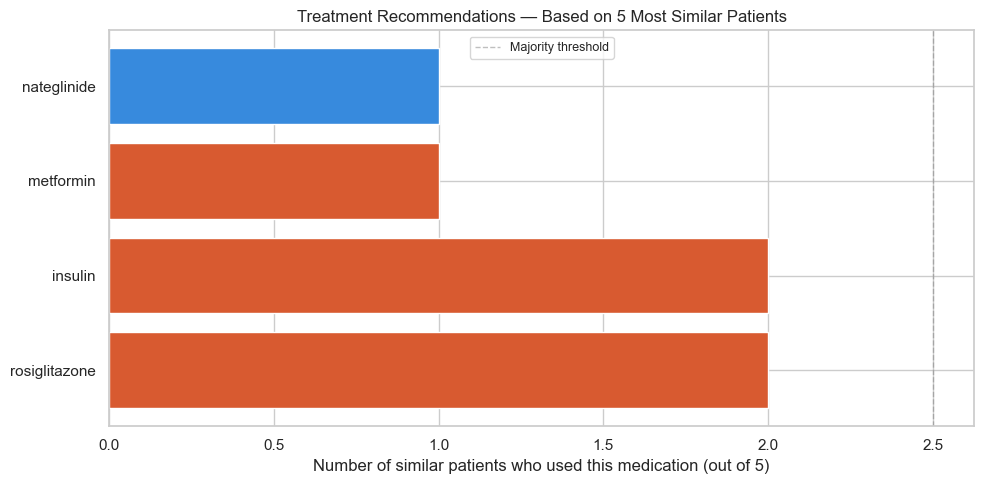

✓ Saved → outputs/treatment_recommendations.png


In [10]:
result_viz = recommend_treatment(sample_patient, top_n=len(med_cols))
all_recs = pd.DataFrame(result_viz['recommendations'])

if not all_recs.empty:
    plt.figure(figsize=(10, 5))
    colors = ['#D85A30' if i < 3 else '#378ADD'
              for i in range(len(all_recs))]

    bars = plt.barh(all_recs['medication'],
                    all_recs['used_by'],
                    color=colors, edgecolor='white')

    plt.xlabel('Number of similar patients who used this medication (out of 5)')
    plt.title('Treatment Recommendations — Based on 5 Most Similar Patients')
    plt.axvline(x=2.5, color='gray', linestyle='--',
                linewidth=1, alpha=0.5, label='Majority threshold')
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('../outputs/treatment_recommendations.png', dpi=150)
    plt.show()
    print("✓ Saved → outputs/treatment_recommendations.png")

---
## Recommendation Engine Summary

### How it works
| Step | What happens |
|---|---|
| Input | New patient health profile (6 features) |
| Scaling | StandardScaler — same scale for all features |
| kNN search | Find 5 most similar past patients |
| Lookup | Check what medications those 5 patients used |
| Output | Top medications ranked by vote count |

### Model details
| Parameter | Value |
|---|---|
| Algorithm | k-Nearest Neighbours |
| k (neighbours) | 5 |
| Distance metric | Euclidean |
| Training samples | 101,766 |
| Feature columns | 6 |
| Medication columns | 10 |

### Files saved
- `models/knn_recommender.pkl`      — trained kNN model
- `models/recommendation_scaler.pkl` — fitted scaler

---
**This engine powers the Recommend page in the Streamlit app.**  
**Next notebook → `09_shap_explainability.ipynb`**